# 🛰️ LAB: MODELADO NEURONAL APLICADO A SISTEMAS DE NAVEGACIÓN SATELITAL (GNSS)
**Cuaderno Técnico de Desafíos Avanzados: `practica_gnss.ipynb`**

¡Bienvenidos, ingenieros y analistas de la Unidad de Navegación Satelital! El objetivo de este laboratorio práctico es consolidar los conceptos de regresión lineal y no lineal abordados en el taller, aplicándolos directamente sobre los fenómenos físicos, geométricos y atmosféricos que afectan el cálculo de posicionamiento de nuestras estaciones de referencia en tierra.

En los sistemas GNSS operacionales (como GPS o Galileo), nos enfrentamos constantemente a perturbaciones en la propagación de las señales portadoras (bandas L1, L2, E1, E5) y a configuraciones geométricas cambiantes en las constelaciones. Tradicionalmente, estos problemas se mitigan mediante funciones de mapeo estáticas o filtros numéricos heredados. A lo largo de este cuaderno, cambiaremos el paradigma: utilizaremos **TensorFlow y Keras** para obligar a las neuronas artificiales a "deducir" las leyes físicas subyacentes observando únicamente telemetría cruda.

---

### 🧱 NUESTRA HOJA DE RUTA DE INGENIERÍA

Para resolver con éxito cada uno de los desafíos planteados, deberás comportarte como un científico de datos aeroespaciales, aplicando quirúrgicamente la secuencia de desarrollo que hemos venido trabajando:

1. **FASE 0 (Canal de Datos):** Inspeccionar el dataset simulado por el instructor y auditar visualmente el comportamiento del problema antes de entrenar.
2. **ETAPA A (Definición Arquitectónica):** Instanciar la estructura de la red en la memoria volátil del sistema. Deberás seleccionar críticamente el número de capas, la cantidad de neuronas y la **Función de Activación** adecuada según la curvatura o la escala del problema para evitar el estancamiento de los gradientes.
3. **ETAPA B (Compilación Matemática):** Configurar el motor de optimización (`Adam`) y la función de pérdida idónea para castigar los errores de predicción (`MSE`).
4. **ETAPA C (Entrenamiento Dinámico):** Disparar el ciclo iterativo de ajuste de pesos y sesgos (`fit`) confrontando la evolución de la red contra datos de validación independientes.
5. **EVALUACIÓN ANALÍTICA:** Auditar las curvas de aprendizaje y contrastar el veredicto final de la Inteligencia Artificial frente a la realidad física del componente.

---

### 🚨 DINÁMICA DEL LABORATORIO:
Cada sección cuenta con una introducción teórica y un bloque de **Fase 0** preconfigurado que inyectará los datos en tu entorno de ejecución. Tu misión será completar el código faltante en los espacios señalados como **"TU TURNO DE ESCRIBIR CÓDIGO"**. Al finalizar cada reto, podrás contrastar tus resultados con la **Solución Maestra del Docente** para verificar si tu red logró deducir con precisión los parámetros físicos reales. ¡Mucho éxito ingenieros!

### problema 1: Regresión Lineal de Pérdida de Señal por Lluvia (CNR)

**Contexto:** Las señales de radiofrecuencia emitidas por las constelaciones GNSS (bandas L1, L2, E1, E5) sufren atenuación al atravesar la troposfera en condiciones meteorológicas adversas. Para intensidades de lluvia moderadas, la degradación de la relación Señal-a-Ruido ($\Delta\text{CNR}$) exhibe un comportamiento lineal directo respecto a la tasa de precipitación.

**Tu Objetivo:** Diseñar un Perceptrón Unicapa (una sola neurona lineal) que aprenda la tasa de atenuación en dB por cada mm/hr de lluvia observando datos históricos de estaciones de referencia.

#### 📋 Guía de Implementación Paso a Paso:
1. **Fase 0 (Datos):** Ejecuta la celda de simulación para generar el dataset de entrenamiento y validación. Observa la gráfica de dispersión.
2. **Etapa A (Definir):** Instancia un modelo `Sequential` de Keras con una sola capa `Dense` de 1 neurona (`units=1`). Como la entrada es solo la tasa de lluvia, `input_shape` debe ser `[1]`. No utilices ninguna función de activación oculta.
3. **Etapa B (Compilar):** Configura el comando `model.compile` utilizando el optimizador `Adam` (con un learning rate alto de `0.1`) y la función de pérdida `Mean Squared Error (mse)`.
4. **Etapa C (Entrenar):** Lanza el entrenamiento usando `model.fit` por **80 épocas**, inyectando los datos de validación.
5. **Evaluación Analítica:** Grafica las curvas de pérdida y extrae los pesos con `model.layers[0].get_weights()` para interpretar la física que aprendió la neurona.

--> [Fase 0] Exito: Dataset cargado en memoria. Completa las siguientes Etapas.


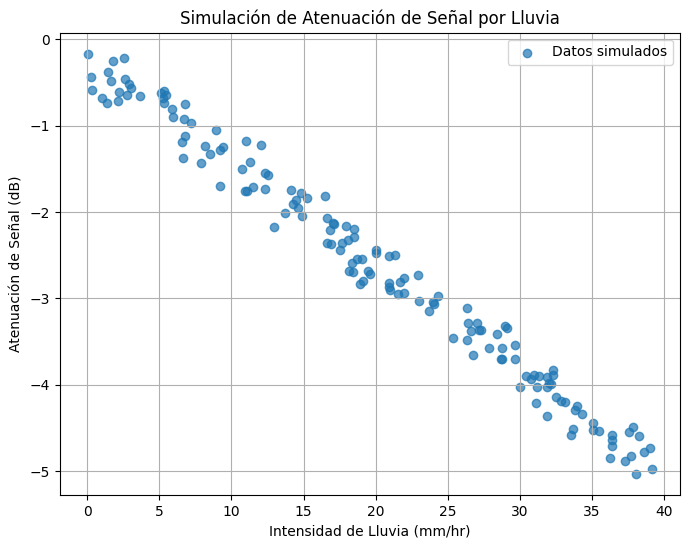

In [1]:

# =====================================================================
# FASE 0: SIMULACIÓN DE TELEMETRÍA METEOROLÓGICA GNSS
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

np.random.seed(7)

# Simulación de intensidad de lluvia (mm/hr)
X_lluvia = np.random.uniform(0.0, 40.0, 150)
# Física real: -0.12 dB por mm/hr de lluvia + un sesgo base de -0.2 dB por pérdidas estáticas
ruido = np.random.normal(0, 0.2, 150)
Y_atenuacion = (-0.12 * X_lluvia) - 0.2 + ruido

# Segmentación de conjuntos (80% Train, 20% Val)
X_train_p1, X_val_p1 = X_lluvia[:120], X_lluvia[120:]
Y_train_p1, Y_val_p1 = Y_atenuacion[:120], Y_atenuacion[120:]

print("--> [Fase 0] Exito: Dataset cargado en memoria. Completa las siguientes Etapas.")

# Graficar los datos simulados
plt.figure(figsize=(8, 6))
plt.scatter(X_lluvia, Y_atenuacion, label='Datos simulados', alpha=0.7)
plt.xlabel('Intensidad de Lluvia (mm/hr)')
plt.ylabel('Atenuación de Señal (dB)')
plt.title('Simulación de Atenuación de Señal por Lluvia')
plt.grid(True)
plt.legend()
plt.show()

In [2]:
# @title Solución Oficial - Problema 1

# =====================================================================
# DESAFÍO 1: TU TURNO DE ESCRIBIR CÓDIGO
# =====================================================================

# 1. ETAPA A: Define el modelo de 1 neurona lineal
model_p1 = keras.Sequential([
    keras.layers.Dense(units=1, input_shape=[1])
])

# 2. ETAPA B: Compila el modelo (Adam 0.1, Pérdida MSE)
model_p1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1), loss='mse')

# 3. ETAPA C: Entrena el modelo por 80 épocas
history_p1 = model_p1.fit(X_train_p1, Y_train_p1, epochs=80, validation_data=(X_val_p1, Y_val_p1), verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


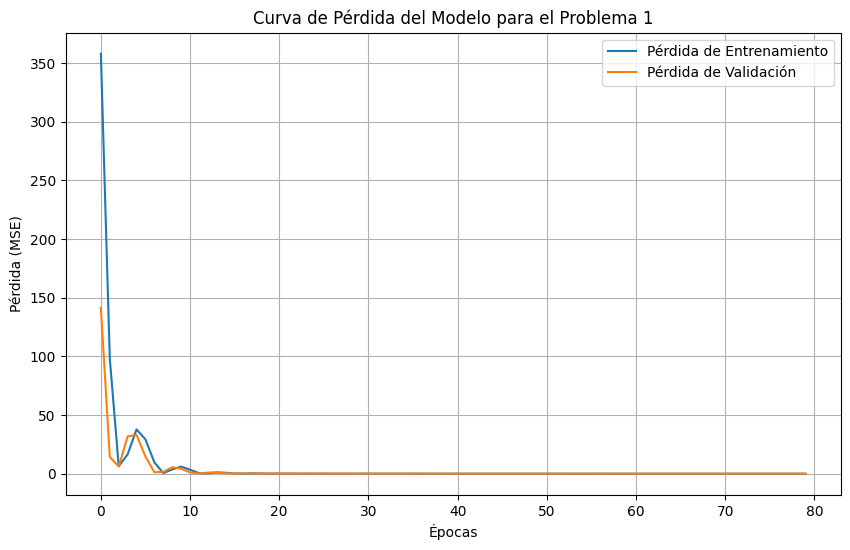

--> [RESULTADO] Parámetros físicos deducidos por la IA:
    Pendiente (Atenuación por mm/hr): -0.1166 dB/mm/hr (Real era: -0.12)
    Sesgo (Pérdida estática base): -0.2931 dB (Real era: -0.2)


In [3]:
# Graficar la curva de pérdida de entrenamiento y validación
plt.figure(figsize=(10, 6))
plt.plot(history_p1.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history_p1.history['val_loss'], label='Pérdida de Validación')
plt.title('Curva de Pérdida del Modelo para el Problema 1')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Extraer y mostrar los pesos aprendidos para interpretar la física
peso, sesgo = model_p1.layers[0].get_weights()
print(f"--> [RESULTADO] Parámetros físicos deducidos por la IA:")
print(f"    Pendiente (Atenuación por mm/hr): {peso[0][0]:.4f} dB/mm/hr (Real era: -0.12)")
print(f"    Sesgo (Pérdida estática base): {sesgo[0]:.4f} dB (Real era: -0.2)")

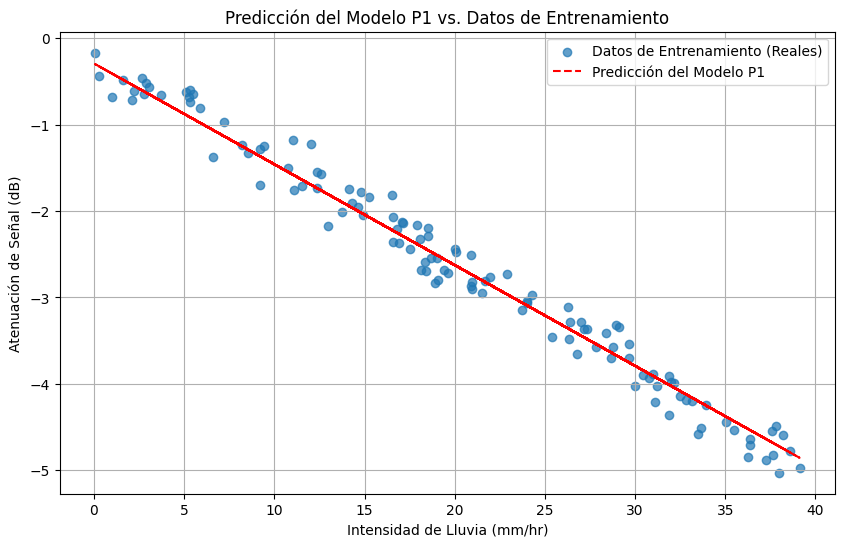

In [4]:
# Obtener las predicciones del modelo para los datos de entrenamiento
Y_pred_p1 = model_p1.predict(X_train_p1, verbose=0).flatten()

# Graficar los datos de entrenamiento y las predicciones
plt.figure(figsize=(10, 6))
plt.scatter(X_train_p1, Y_train_p1, label='Datos de Entrenamiento (Reales)', alpha=0.7)
plt.plot(X_train_p1, Y_pred_p1, color='red', linestyle='--', label='Predicción del Modelo P1')
plt.title('Predicción del Modelo P1 vs. Datos de Entrenamiento')
plt.xlabel('Intensidad de Lluvia (mm/hr)')
plt.ylabel('Atenuación de Señal (dB)')
plt.legend()
plt.grid(True)
plt.show()

### problema 2: Introducción a la No Linealidad Atmosférica

**Contexto:** El retraso ionosférico y troposférico de una señal GNSS no es constante; depende del **Ángulo de Elevación** del satélite respecto al horizonte del receptor. Si el satélite está directamente sobre el cenit ($90^\circ$), cruza una sola capa de atmósfera ("Masa de Aire = 1"). Si baja hacia el horizonte ($10^\circ$), la señal atraviesa un volumen de atmósfera masivo, curvando y retrasando la señal de forma no lineal.



**Tu Objetivo:** Entrenar una Red Neuronal Profunda (MLP) capaz de "curvar" su espacio matemático para aproximar el retraso atmosférico en metros basándose en el ángulo de elevación del satélite.

#### 📋 Guía de Implementación Paso a Paso:
1. **Fase 0 (Datos):** Ejecuta la celda del instructor. Verás que la relación entre el ángulo ($X$) y el retraso en metros ($Y$) es inversamente proporcional y curva.
2. **Etapa A (Definir):** Construye un modelo secuencial con capas ocultas profundas para romper la linealidad. Requisitos de hardware lógico:
   - Capa Oculta 1: `Dense` con **32 neuronas** y función de activación **Tangente Hiperbólica (`'tanh'`)**.
   - Capa Oculta 2: `Dense` con **16 neuronas** y activación `'tanh'`.
   - Capa de Salida: **1 neurona** lineal (sin activación, ya que predice metros continuos).
3. **Etapa B (Compilar):** Utiliza el optimizador `Adam` con una tasa de aprendizaje controlada de `0.01` y pérdida `mse`.
4. **Etapa C (Entrenar):** Entrena el modelo por **150 épocas** inyectando las variables de entrenamiento y validación.

--> [Fase 0] Éxito: Curva atmosférica no lineal instanciada en memoria.


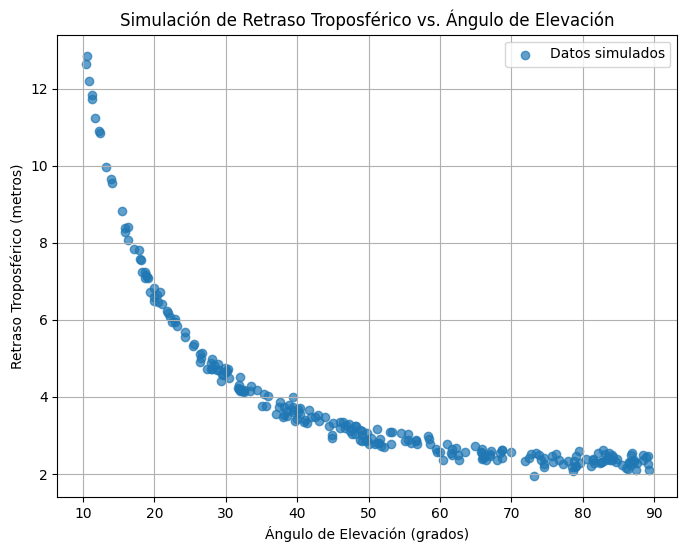

In [5]:
# =====================================================================
# FASE 0: SIMULACIÓN DE RETRASO TROPOSFÉRICO (MAPPING FUNCTION)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

X_angulo = np.random.uniform(10.0, 90.0, 250)
# Física real: Relación asintótica inversa (Masa de aire = 1 / sin(elevacion))
Y_retraso_metros = (2.3 / np.sin(np.radians(X_angulo))) + np.random.normal(0, 0.15, 250)

X_train_p2, X_val_p2 = X_angulo[:200], X_angulo[200:]
Y_train_p2, Y_val_p2 = Y_retraso_metros[:200], Y_retraso_metros[200:]

print("--> [Fase 0] Éxito: Curva atmosférica no lineal instanciada en memoria.")

# Graficar los datos simulados
plt.figure(figsize=(8, 6))
plt.scatter(X_angulo, Y_retraso_metros, label='Datos simulados', alpha=0.7)
plt.xlabel('Ángulo de Elevación (grados)')
plt.ylabel('Retraso Troposférico (metros)')
plt.title('Simulación de Retraso Troposférico vs. Ángulo de Elevación')
plt.grid(True)
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


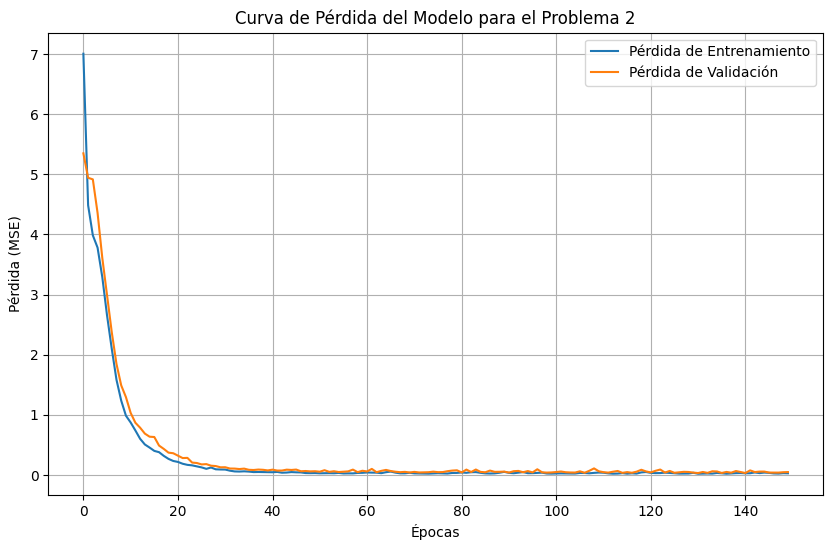

In [6]:
# @title Solución Oficial - Problema 2

# =====================================================================
# DESAFÍO 2: TU TURNO DE ESCRIBIR CÓDIGO (MODELO NO LINEAL)
# =====================================================================

# 1. ETAPA A: Declara la red profunda con activaciones 'tanh'
model_p2 = keras.Sequential([
    keras.layers.Dense(units=32, activation='tanh', input_shape=[1]),
    keras.layers.Dense(units=16, activation='tanh'),
    keras.layers.Dense(units=1)
])

# 2. ETAPA B: Compila el modelo (Adam 0.01, Pérdida MSE)
model_p2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse')

# 3. ETAPA C: Entrena el modelo por 150 épocas
history_p2 = model_p2.fit(X_train_p2, Y_train_p2, epochs=150, validation_data=(X_val_p2, Y_val_p2), verbose=0)

# Graficar la curva de pérdida de entrenamiento y validación
plt.figure(figsize=(10, 6))
plt.plot(history_p2.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history_p2.history['val_loss'], label='Pérdida de Validación')
plt.title('Curva de Pérdida del Modelo para el Problema 2')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()

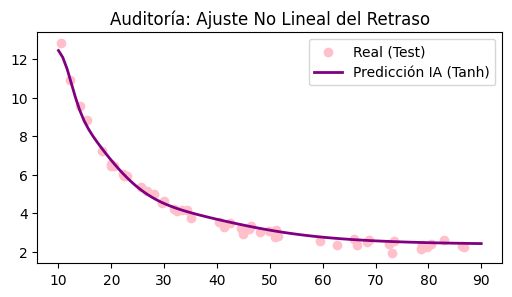

In [7]:
# Graficar ajuste final para auditoría
plt.figure(figsize=(6,3))
plt.scatter(X_val_p2, Y_val_p2, color='pink', label='Real (Test)')
X_grid = np.linspace(10, 90, 100)
plt.plot(X_grid, model_p2.predict(X_grid, verbose=0), color='purple', lw=2, label='Predicción IA (Tanh)')
plt.title("Auditoría: Ajuste No Lineal del Retraso")
plt.legend()
plt.show()

### problema 3: El Límite de ReLU ante Escalas Salvajes (Geometría Satelital DOP)

**Contexto:** El factor **DOP (Dilution of Precision)** evalúa cualitativamente la geometría de los satélites GNSS visibles en el cielo. Si los satélites están excesivamente aglomerados o alineados en una misma zona del espacio (poca separación angular), el error geométrico se dispara asintóticamente hacia valores críticos (DOP > 50). Si están bien dispersos, el DOP es óptimo e ideal (DOP cercano a 1). Esta oscilación brutal de magnitudes genera lo que los ingenieros de IA llamamos una "escala salvaje".

**Tu Objetivo:** Descubrir por qué la función de activación convencional `ReLU` colapsa ante estas variaciones extremas y solucionar el problema utilizando funciones de gradiente continuo como **Softplus**.

#### 📋 Guía de Implementación Paso a Paso:
1. **Fase 0 (Datos):** Ejecuta la celda del instructor para generar los perfiles geométricos.
2. **Etapa A (Definición de Resiliencia):** Construye un modelo secuencial profundo. **¡Alerta!** Si utilizas `activation='relu'`, los gradientes de entrada se estancarán y la red morirá dando una respuesta plana en cero (*Dying ReLU*). Configura las capas ocultas utilizando la función de activación **`'softplus'`** o **`'elu'`**:
   - Capa Oculta 1: `Dense` con **64 neuronas** y `activation='softplus'`.
   - Capa Oculta 2: `Dense` con **32 neuronas** y `activation='softplus'`.
   - Capa de Salida: **1 neurona** lineal.
3. **Etapa B y C:** Compila con `Adam(learning_rate=0.005)` y pérdida `mse`. Entrena por **200 épocas**.

--> [Fase 0] Éxito: Dataset alfanumérico de escala salvaje (DOP) cargado.


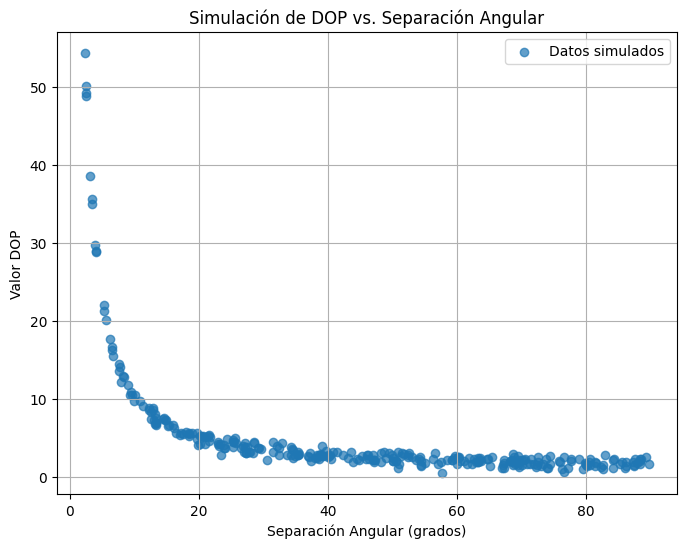

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# FASE 0: SIMULACIÓN DE GEOMETRÍA DE CONSTELACIÓN (HDOP/VDOP)
# =====================================================================
X_separacion_angular = np.random.uniform(2.0, 90.0, 300)
# Física real: Comportamiento asintótico exponencial severo
Y_dop = (150.0 / (X_separacion_angular ** 1.2)) + 1.0 + np.random.normal(0, 0.5, 300)

X_train_p3, X_val_p3 = X_separacion_angular[:240], X_separacion_angular[240:]
Y_train_p3, Y_val_p3 = Y_dop[:240], Y_dop[240:]

print("--> [Fase 0] Éxito: Dataset alfanumérico de escala salvaje (DOP) cargado.")

# Graficar los datos simulados
plt.figure(figsize=(8, 6))
plt.scatter(X_separacion_angular, Y_dop, label='Datos simulados', alpha=0.7)
plt.xlabel('Separación Angular (grados)')
plt.ylabel('Valor DOP')
plt.title('Simulación de DOP vs. Separación Angular')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
# @title Solución Oficial - Problema 3
# =====================================================================
# DESAFÍO 3: TU TURNO DE ESCRIBIR CÓDIGO (PROTECCIÓN DE GRADIENTES)
# =====================================================================

# 1. ETAPA A: Define el modelo usando la activación protectora inmune a escalas salvajes
model_p3 = keras.Sequential([
    keras.layers.Dense(units=64, activation='softplus', input_shape=[1]),
    keras.layers.Dense(units=32, activation='softplus'),
    keras.layers.Dense(units=1)
])

# 2. ETAPA B: Compila el modelo
model_p3.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='mse')
history_p3 = model_p3.fit(X_train_p3, Y_train_p3, epochs=200, validation_data=(X_val_p3, Y_val_p3), verbose=0)

# 3. ETAPA C: Entrena el modelo por 200 épocas
mse_final = history_p3.history['val_loss'][-1]
print(f"--> [ÉXITO] Entrenamiento finalizado de forma estable.")
print(f"    Error Cuadrático Medio final en Validación: {mse_final:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--> [ÉXITO] Entrenamiento finalizado de forma estable.
    Error Cuadrático Medio final en Validación: 0.1914


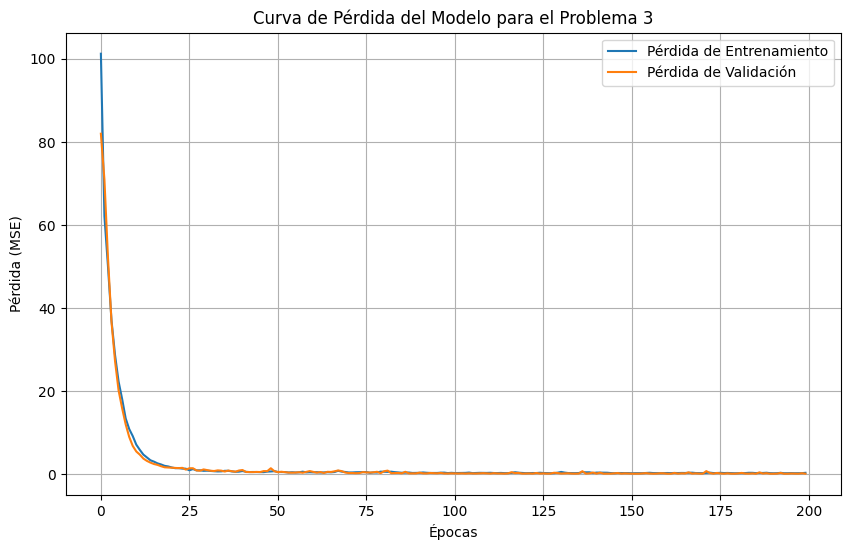

In [10]:
# Graficar la curva de pérdida de entrenamiento y validación
plt.figure(figsize=(10, 6))
plt.plot(history_p3.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history_p3.history['val_loss'], label='Pérdida de Validación')
plt.title('Curva de Pérdida del Modelo para el Problema 3')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()

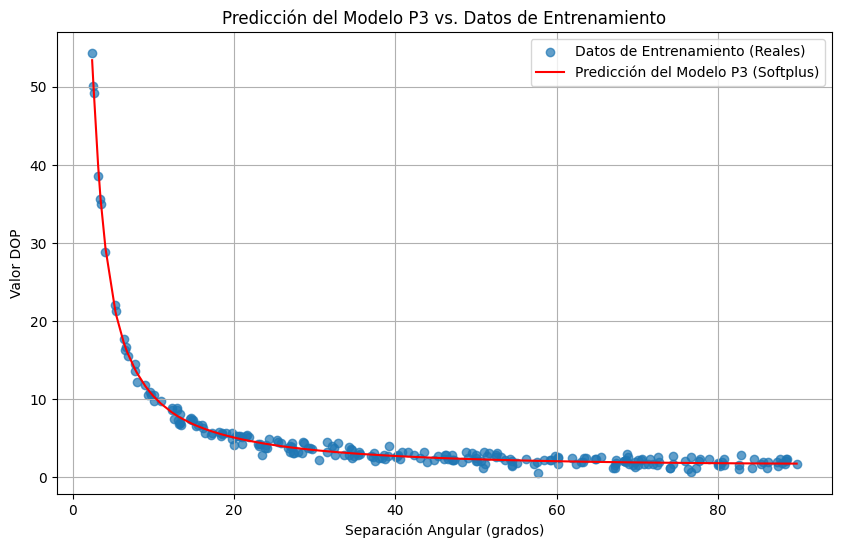

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener las predicciones del modelo para los datos de entrenamiento
Y_pred_p3 = model_p3.predict(X_train_p3, verbose=0).flatten()

# Crear un rango ordenado para X_train_p3 para graficar la línea de predicción suave
sorted_indices = np.argsort(X_train_p3)
X_train_p3_sorted = X_train_p3[sorted_indices]
Y_pred_p3_sorted = Y_pred_p3[sorted_indices]

# Graficar los datos de entrenamiento y las predicciones
plt.figure(figsize=(10, 6))
plt.scatter(X_train_p3, Y_train_p3, label='Datos de Entrenamiento (Reales)', alpha=0.7)
plt.plot(X_train_p3_sorted, Y_pred_p3_sorted, color='red', linestyle='-', label='Predicción del Modelo P3 (Softplus)')
plt.title('Predicción del Modelo P3 vs. Datos de Entrenamiento')
plt.xlabel('Separación Angular (grados)')
plt.ylabel('Valor DOP')
plt.legend()
plt.grid(True)
plt.show()